In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
print(train['label'].unique())
train.head(2)

[2 0 1 3]


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0


In [3]:
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)


In [5]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [6]:
# target variable ie label distn
print(train['label'].value_counts())
print(train['label'].value_counts(normalize=True))

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64
label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [7]:
print(train.dtypes)

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


In [8]:
print(train.isnull().sum(),"\n\n")
print(test.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64 


created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


In [9]:
# text stats
train['comment_length'] = train['comment'].astype(str).apply(len)
train['word_count'] = train['comment'].astype(str).apply(lambda x: len(x.split()))

print(train['comment_length'].describe(),"\n")
print(train['word_count'].describe(),"\n")
print("Duplicate comments:", train['comment'].duplicated().sum())

count    198000.000000
mean        302.909379
std         266.441732
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64 

count    198000.000000
mean         52.396990
std          45.770215
min           1.000000
25%          18.000000
50%          37.000000
75%          73.000000
max         315.000000
Name: word_count, dtype: float64 

Duplicate comments: 157


In [10]:
print(train[['upvote','downvote']].describe())

              upvote       downvote
count  198000.000000  198000.000000
mean        2.607975       0.666394
std         5.054763       2.044335
min         0.000000       0.000000
25%         0.000000       0.000000
50%         1.000000       0.000000
75%         3.000000       1.000000
max       201.000000     107.000000


In [11]:
train['created_date'] = pd.to_datetime(train['created_date'])

print(train['created_date'].min())
print(train['created_date'].max())

2022-04-29 14:50:48.488476+00:00
2024-06-11 04:41:08.821674+00:00


In [12]:
print("Unique post_ids:", train['post_id'].nunique())

Unique post_ids: 52


In [13]:
# EDA to undertsand the data

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

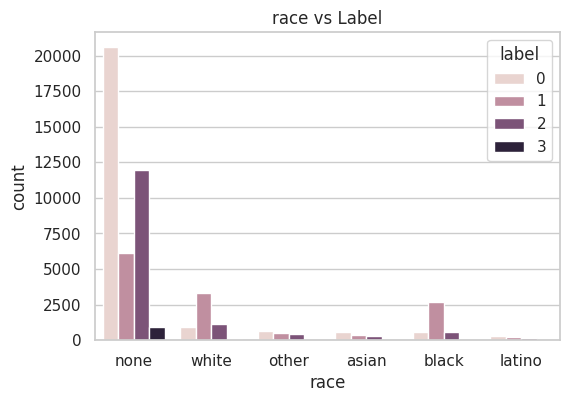

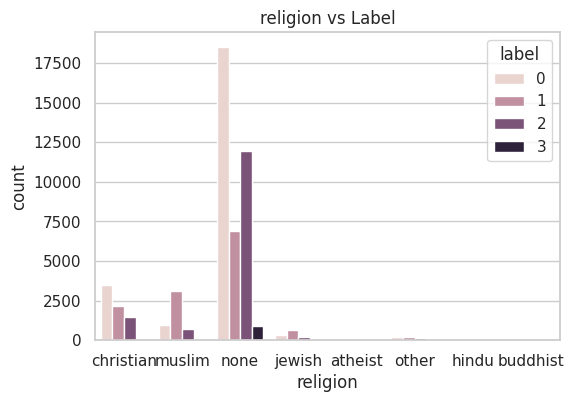

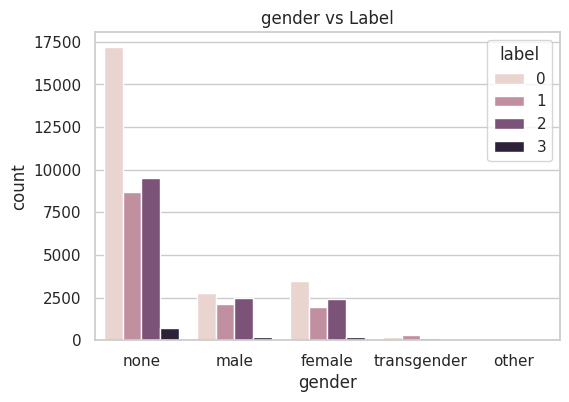

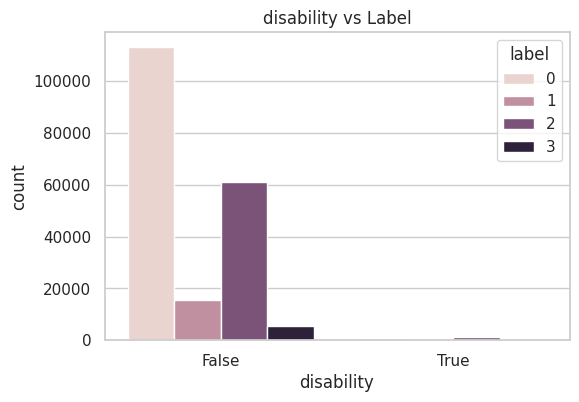

In [14]:
cols_1 = ["race","religion","gender", "disability"]
for col in cols_1:
    plt.figure(figsize=(6,4))
    sns.countplot(x=train[col], hue=train['label'])
    plt.title(f"{col} vs Label")
    plt.show()

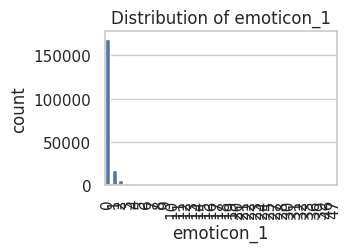

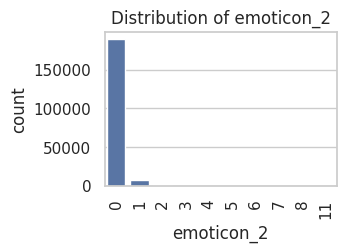

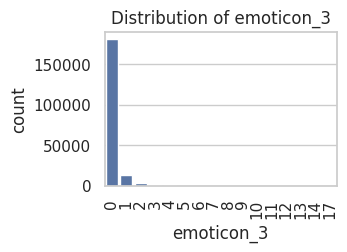

In [15]:
cols_2 = ["emoticon_1","emoticon_2","emoticon_3"]

for col in cols_2:
    plt.figure(figsize=(3,2))
    sns.countplot(x=train[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=90)
    plt.show()

In [16]:
cols_3 = ["if_1","if_2"]

for c in cols_3:
    print(train[c].value_counts(dropna=False)[:10],"\n")

if_1
0       145423
4        31061
10       11849
6         6774
5         2691
7           70
9           45
11          32
12           2
1814         2
Name: count, dtype: int64 

if_2
4     91726
10    80693
6     14558
5      6188
70      453
7       366
11      312
80      286
64      281
74      238
Name: count, dtype: int64 



In [17]:
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

for col in ["race","religion","gender"]:
    train[col] = train[col].fillna("none")
    test[col] = test[col].fillna("none")

train['disability'] = train['disability'].astype(int)
test['disability'] = test['disability'].astype(int)

In [18]:
train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

for df in [train, test]:
    df["year"] = df["created_date"].dt.year
    df["month"] = df["created_date"].dt.month
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["hour"] = df["created_date"].dt.hour

In [19]:
# comment feats:=
for df in [train, test]:
    df["comment_length"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].apply(lambda x: len(x.split()))

# vote feats:=
for df in [train, test]:
    df["vote_score"] = df["upvote"] - df["downvote"]
    # df["vote_ratio"] = df["upvote"] / (df["downvote"] + 1)

In [20]:
train.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,disability,comment,label,comment_length,word_count,year,month,dayofweek,hour,vote_score
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,none,...,0,She might be a bright spot for a party keou on...,2,118,20,2024,1,3,8,-1
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,none,...,0,"Under Alaska law, a non-tribal member is not b...",0,644,110,2024,3,6,21,6


# approach 1

In [21]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [23]:
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

for col in ["race", "religion", "gender"]:
    train[col] = train[col].fillna("none")
    test[col] = test[col].fillna("none")

In [24]:
train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

for df in [train, test]:

    df["year"] = df["created_date"].dt.year
    df["month"] = df["created_date"].dt.month
    df["dayofweek"] = df["created_date"].dt.dayofweek

    df["comment_length"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].apply(lambda x: len(x.split()))

    df["vote_score"] = df["upvote"] - df["downvote"]

    df["disability"] = df["disability"].astype(int)


train = train.drop(columns=["created_date"])
test = test.drop(columns=["created_date"])

In [25]:
X = train.drop("label", axis=1)
y = train["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
categorical_cols = ["race", "religion", "gender"]

numerical_cols = ["post_id","emoticon_1","emoticon_2","emoticon_3","upvote", "downvote",
                  "vote_score","if_1", "if_2","disability",
                  "year","month","dayofweek","comment_length","word_count"
                 ]

def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [27]:
text_pipeline = Pipeline([
    ("normalize", FunctionTransformer(lambda x: x.apply(normalize_text))),
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=3,
        max_features=40000
    )
    )
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler(with_mean=False))
])

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_pipeline, "comment"),
        ("cat", categorical_pipeline, categorical_cols),
        ("num", numeric_pipeline, numerical_cols)
    ]
)

X_train_final = preprocessor.fit_transform(X_train)
X_valid_final = preprocessor.transform(X_valid)
X_test_final = preprocessor.transform(test)

In [29]:
print("Train:", X_train_final.shape)
print("Valid:", X_valid_final.shape)
print("Test:", X_test_final.shape)

Train: (158400, 40034)
Valid: (39600, 40034)
Test: (102000, 40034)


In [30]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score


### model 1

In [31]:
ada_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=2306
)

ada_model.fit(X_train_final, y_train)

AdaBoostClassifier(random_state=2306)

In [32]:
train_pred_ada = ada_model.predict(X_train_final)
valid_pred_ada = ada_model.predict(X_valid_final)

print("AdaBoost Training Accuracy:", accuracy_score(y_train, train_pred_ada))
print("AdaBoost Validation Accuracy:", accuracy_score(y_valid, valid_pred_ada))

f1_train = f1_score(y_train, train_pred_ada, average='weighted')
print("f1 score train:", f1_train)
f1_valid = f1_score(y_valid, valid_pred_ada, average='weighted')
print("f1 score valid:", f1_valid)

AdaBoost Training Accuracy: 0.8770707070707071
AdaBoost Validation Accuracy: 0.8783838383838384
f1 score train: 0.8652198721431259
f1 score valid: 0.8663420806219835


In [33]:
f1_train = f1_score(y_train, train_pred_ada, average='macro')
print("f1 score train:", f1_train)
f1_valid = f1_score(y_valid, valid_pred_ada, average='macro')
print("f1 score valid:", f1_valid)

f1 score train: 0.617463950144302
f1 score valid: 0.6155758510876893


### model 2

In [34]:
svm_model = LinearSVC(class_weight='balanced')

svm_model.fit(X_train_final, y_train)

LinearSVC(class_weight='balanced')

In [35]:
train_pred = svm_model.predict(X_train_final)
valid_pred = svm_model.predict(X_valid_final)

print("Train F1:", f1_score(y_train, train_pred, average="weighted"))
print("Valid F1:", f1_score(y_valid, valid_pred, average="weighted"))

Train F1: 0.5913943482210616
Valid F1: 0.5839983088805643


### model 3

In [36]:
sgd_model = SGDClassifier(
    loss="log_loss",      # logistic regression
    penalty="l2",
    alpha=1e-5,
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

sgd_model.fit(X_train_final, y_train)

SGDClassifier(alpha=1e-05, class_weight='balanced', loss='log_loss',
              max_iter=2000, n_jobs=-1, random_state=42)

In [37]:
train_pred = sgd_model.predict(X_train_final)
valid_pred = sgd_model.predict(X_valid_final)

print("SGD Train F1:", f1_score(y_train, train_pred, average="weighted"))
print("SGD Valid F1:", f1_score(y_valid, valid_pred, average="weighted"))

SGD Train F1: 0.45820945954224657
SGD Valid F1: 0.4558948421670142


## Testing part

In [38]:
# test_predictions = best_model.predict(X_test_final)
# test_predictions = ada_model.predict(X_test_final)

# submission_df = pd.DataFrame({"ID": range(1, len(test) + 1),
#                               "label": test_predictions
#                              })
# submission_df.to_csv('submission.csv', index=False)

# submission_df.head()

In [39]:
# print(submission_df['label'].value_counts())
# print(submission_df['label'].value_counts(normalize=True))

# approach 2

In [40]:
import re
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import lightgbm as lgb

from sklearn.pipeline import FeatureUnion

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [41]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [42]:
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

for col in ["race", "religion", "gender"]:
    train[col] = train[col].fillna("none")
    test[col] = test[col].fillna("none")

train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

for df in [train, test]:
    df["year"] = df["created_date"].dt.year
    df["month"] = df["created_date"].dt.month
    df["dayofweek"] = df["created_date"].dt.dayofweek
    
    df["comment_length"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].apply(lambda x: len(x.split()))
    
    df["vote_score"] = df["upvote"] - df["downvote"]
    df["disability"] = df["disability"].astype(int)

train = train.drop(columns=["created_date"])
test = test.drop(columns=["created_date"])

In [43]:
post_freq_train = train.groupby('post_id')['post_id'].transform('count')
post_freq_test = test.groupby('post_id')['post_id'].transform('count')

train['post_freq'] = post_freq_train
test['post_freq'] = post_freq_test

train.drop('post_id', axis=1, inplace=True)
test.drop('post_id', axis=1, inplace=True)

In [44]:
categorical_cols = ["race", "religion", "gender"]

numerical_cols = ["emoticon_1","emoticon_2","emoticon_3","upvote", "downvote",
                  "vote_score","if_1", "if_2","disability",
                  "year","month","dayofweek","comment_length","word_count",
                  "post_freq"]  

In [45]:
def normalize_text(text): # basic text cleaning
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [46]:
text_pipeline = Pipeline([
    ("normalize", FunctionTransformer(lambda x: x.apply(normalize_text))),
    ("tfidf", FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),      
            max_features=50000,
            stop_words='english',
            sublinear_tf=True,
            min_df=2,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
            sublinear_tf=True,
            min_df=3,
        )),
    ]))
])

In [47]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler(with_mean=False))   # keep sparse if possible
])


preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_pipeline, "comment"),
        ("cat", categorical_pipeline, categorical_cols),
        ("num", numeric_pipeline, numerical_cols)
    ],
    sparse_threshold=1.0      # force sparse matrix output
)

In [48]:
X = train.drop("label", axis=1)
y = train["label"]

X_transformed = preprocessor.fit_transform(X)
X_test_final = preprocessor.transform(test)

print("Train shape:", X_transformed.shape)
print("Test shape :", X_test_final.shape)

Train shape: (198000, 80034)
Test shape : (102000, 80034)


In [49]:
X_train_final, X_valid_final, y_train_final, y_valid_final = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [50]:
classes = np.unique(y_train_final)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_final
)

sample_weights = class_weights[y_train_final]
sample_weights

array([0.43355449, 0.43355449, 0.79276105, ..., 0.43355449, 0.43355449,
       0.79276105])

In [51]:
final_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_valid_final, y_valid_final)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 98.444549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6429848
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 53304
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.288031
[200]	valid_0's multi_logloss: 0.260166
[300]	valid_0's multi_logloss: 0.25645
Early stopping, best iteration is:
[289]	valid_0's multi_logloss: 0.256214


LGBMClassifier(class_weight='balanced', colsample_bytree=0.7,
               learning_rate=0.05, n_estimators=1000, n_jobs=-1, num_leaves=127,
               random_state=42, subsample=0.8)

In [52]:
pred_train = final_model.predict(X_train_final)
f1_macro_train = f1_score(y_train_final, pred_train, average="macro")

pred_valid = final_model.predict(X_valid_final)
f1_macro_valid = f1_score(y_valid_final, pred_valid, average="macro")

print("Train Macro F1:", f1_macro_train)
print("Validation Macro F1:", f1_macro_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train Macro F1: 0.9807086779568518
Validation Macro F1: 0.8322691946965186


## HPT

In [53]:
# param_dist = {
#     "n_estimators": [500, 800, 1200],
#     "learning_rate": [0.03, 0.05, 0.08],
#     "num_leaves": [63, 127, 255],
#     "max_depth": [-1, 10, 20],
    
#     "subsample": [0.7, 0.8, 0.9],
#     "colsample_bytree": [0.6, 0.7, 0.8],

#     "reg_alpha": [0, 0.1, 0.5, 1],
#     "reg_lambda": [0, 0.1, 0.5, 1],
    
#     "min_child_samples": [20, 50, 100]
# }

In [54]:
# # base model
# lgb_model = lgb.LGBMClassifier(
#     objective="multiclass",
#     class_weight="balanced",
#     random_state=42,
#     n_jobs=-1
# )

# # randomized search
# random_search = RandomizedSearchCV(
#     estimator=lgb_model,
#     param_distributions=param_dist,
#     n_iter=20,  
#     scoring="f1_macro",
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

In [55]:
# random_search.fit(
#     X_train_final, y_train_final,
#     eval_set=[(X_valid_final, y_valid_final)],
#     callbacks=[lgb.early_stopping(50)],
# )

In [56]:
# print("Best Params:", random_search.best_params_)
# best_model = random_search.best_estimator_

# pred_valid = best_model.predict(X_valid_final)
# print("Validation Macro F1:", f1_score(y_valid_final, pred_valid, average="macro"))

## Feature Importance Visualization

In [57]:
import matplotlib.pyplot as plt
import lightgbm as lgb

<Figure size 1000x2000 with 0 Axes>

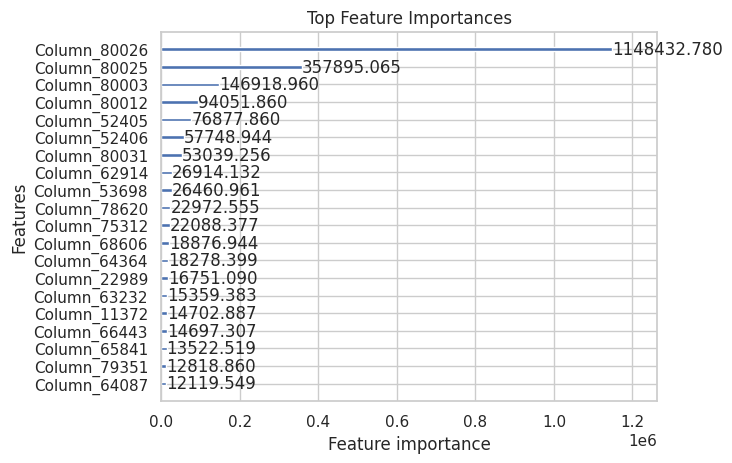

In [58]:
plt.figure(figsize=(10, 20))

lgb.plot_importance(
    final_model,
    max_num_features=20,
    importance_type='gain'
)

plt.title("Top Feature Importances")
plt.show()

## Testing part

In [59]:
test_preds = final_model.predict(X_test_final)

submission = pd.DataFrame({
    "ID": range(1, len(test) + 1),         
    'label': test_preds
})

print(submission['label'].value_counts())
print(submission['label'].value_counts(normalize=True))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


label
0    56659
2    33124
1     9234
3     2983
Name: count, dtype: int64
label
0    0.555480
2    0.324745
1    0.090529
3    0.029245
Name: proportion, dtype: float64


In [60]:
submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")

Submission saved to submission.csv
